<a href="https://colab.research.google.com/github/4518kiet-coder/Student_Grading/blob/main/Student_Grading.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:

# ============================================================
# B.Tech Mathematics Mini Project
# Student Grade Curving System (A8)
# ============================================================

"""
PROBLEM:
Three professors teach the same subject, but their exams have
different difficulty levels.

Goal:
Adjust grades so that the groups have comparable:
1. Mean
2. Standard deviation

IMPORTANT MATHEMATICAL ASSUMPTION:
We use an affine transformation for each professor:

        y = a*x + b

where:
    x = original grade
    y = adjusted grade
    a = scaling factor
    b = shifting factor

For professor i:

        a_i = target_SD / original_SD_i

        b_i = target_mean - a_i * original_mean_i

This is the standard linear normalization method.

The target mean and target SD are selected from the
three groups using their overall average values.
"""

print("Student Grade Curving System (A8)")
print("Affine normalization + 3x3 Gauss elimination")

Student Grade Curving System (A8)
Affine normalization + 3x3 Gauss elimination


In [7]:
# ============================================================
# IMPORTS
# ============================================================

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

from IPython.display import display

In [8]:
# ============================================================
# USER INPUTS
# ============================================================

print("==============================================")
print("       STUDENT GRADE CURVING SYSTEM")
print("==============================================")

# Number of professors
num_professors = 3

professors = []

for i in range(num_professors):

    print(f"\n--- Professor {i+1} ---")

    name = input("Enter professor name: ")

    grades_input = input(
        "Enter grades separated by spaces (example: 45 50 55 60 65): "
    )

    # Convert entered values into numbers
    grades = np.array(
        [float(x) for x in grades_input.split()],
        dtype=float
    )

    professors.append({
        "name": name,
        "grades": grades
    })

print("\nInput accepted successfully!")

for p in professors:
    print(f"{p['name']}: {p['grades']}")

       STUDENT GRADE CURVING SYSTEM

--- Professor 1 ---



KeyboardInterrupt



In [9]:

# ============================================================
# OPTIONAL: CLEAN CONFIGURATION INPUT
# ============================================================

professors = [
    {
        "name": "Professor A",
        "grades": np.array([45, 50, 55, 60, 65], dtype=float)
    },
    {
        "name": "Professor B",
        "grades": np.array([55, 60, 65, 70, 75], dtype=float)
    },
    {
        "name": "Professor C",
        "grades": np.array([35, 45, 55, 65, 75], dtype=float)
    }
]

print("Configuration loaded successfully.")

for p in professors:
    print(p["name"], ":", p["grades"])

Configuration loaded successfully.
Professor A : [45. 50. 55. 60. 65.]
Professor B : [55. 60. 65. 70. 75.]
Professor C : [35. 45. 55. 65. 75.]


In [10]:

# ============================================================
# ORIGINAL STATISTICS
# ============================================================

for p in professors:

    grades = p["grades"]

    p["mean"] = np.mean(grades)

    # Population standard deviation
    p["std"] = np.std(grades)

    p["variance"] = np.var(grades)

    print(f"\n{p['name']}")
    print("-" * 30)
    print(f"Mean      = {p['mean']:.4f}")
    print(f"Variance  = {p['variance']:.4f}")
    print(f"Std Dev   = {p['std']:.4f}")


Professor A
------------------------------
Mean      = 55.0000
Variance  = 50.0000
Std Dev   = 7.0711

Professor B
------------------------------
Mean      = 65.0000
Variance  = 50.0000
Std Dev   = 7.0711

Professor C
------------------------------
Mean      = 55.0000
Variance  = 200.0000
Std Dev   = 14.1421


In [11]:
# ============================================================
# TARGET MEAN AND TARGET STANDARD DEVIATION
# ============================================================

target_mean = np.mean([
    p["mean"] for p in professors
])

target_std = np.mean([
    p["std"] for p in professors
])

print("==============================================")
print("TARGET STATISTICS")
print("==============================================")

print(f"Target Mean = {target_mean:.4f}")
print(f"Target SD   = {target_std:.4f}")

TARGET STATISTICS
Target Mean = 58.3333
Target SD   = 9.4281


In [12]:
# ============================================================
# MATHEMATICAL MODEL
# ============================================================

print("""
MATHEMATICAL MODEL

For each professor:

    y = a*x + b

Mean condition:

    Mean(y) = a*Mean(x) + b

We require:

    a*Mean(x) + b = Target Mean

Standard-deviation condition:

    SD(y) = |a|*SD(x)

For positive scaling:

    a*SD(x) = Target SD

Therefore:

    a = Target SD / SD(x)

and

    b = Target Mean - a*Mean(x)
""")


MATHEMATICAL MODEL

For each professor:

    y = a*x + b

Mean condition:

    Mean(y) = a*Mean(x) + b

We require:

    a*Mean(x) + b = Target Mean

Standard-deviation condition:

    SD(y) = |a|*SD(x)

For positive scaling:

    a*SD(x) = Target SD

Therefore:

    a = Target SD / SD(x)

and

    b = Target Mean - a*Mean(x)



In [13]:
# ============================================================
# CALCULATE AFFINE SCALING PARAMETERS
# ============================================================

for p in professors:

    original_mean = p["mean"]
    original_std = p["std"]

    # Scaling factor
    a = target_std / original_std

    # Shifting factor
    b = target_mean - a * original_mean

    p["a"] = a
    p["b"] = b

    print(f"\n{p['name']}")
    print("-" * 30)
    print(f"Scaling factor a = {a:.6f}")
    print(f"Shift factor b   = {b:.6f}")


Professor A
------------------------------
Scaling factor a = 1.333333
Shift factor b   = -15.000000

Professor B
------------------------------
Scaling factor a = 1.333333
Shift factor b   = -28.333333

Professor C
------------------------------
Scaling factor a = 0.666667
Shift factor b   = 21.666667


In [14]:
# ============================================================
# APPLY GRADE TRANSFORMATION
# ============================================================

for p in professors:

    x = p["grades"]

    a = p["a"]
    b = p["b"]

    # Affine transformation
    adjusted = a * x + b

    p["adjusted_grades"] = adjusted

    # Calculate adjusted statistics
    p["adjusted_mean"] = np.mean(adjusted)
    p["adjusted_std"] = np.std(adjusted)
    p["adjusted_variance"] = np.var(adjusted)

In [15]:
# ============================================================
# OUTPUT TABLE
# ============================================================

print("\n==============================================================")
print("                  GRADE CURVING RESULTS")
print("==============================================================")

print(
    f"{'Professor':<18}"
    f"{'Original Mean':<18}"
    f"{'Original SD':<18}"
    f"{'Adjusted Mean':<18}"
    f"{'Adjusted SD':<18}"
)

print("-" * 90)

for p in professors:

    print(
        f"{p['name']:<18}"
        f"{p['mean']:<18.4f}"
        f"{p['std']:<18.4f}"
        f"{p['adjusted_mean']:<18.4f}"
        f"{p['adjusted_std']:<18.4f}"
    )


                  GRADE CURVING RESULTS
Professor         Original Mean     Original SD       Adjusted Mean     Adjusted SD       
------------------------------------------------------------------------------------------
Professor A       55.0000           7.0711            58.3333           9.4281            
Professor B       65.0000           7.0711            58.3333           9.4281            
Professor C       55.0000           14.1421           58.3333           9.4281            


In [16]:
# ============================================================
# INDIVIDUAL GRADE RESULTS
# ============================================================

for p in professors:

    print(f"\n{p['name']}")
    print("-" * 50)

    print(f"{'Original':>12} {'Adjusted':>15}")

    for original, adjusted in zip(
        p["grades"],
        p["adjusted_grades"]
    ):

        print(
            f"{original:>12.2f}"
            f"{adjusted:>15.2f}"
        )


Professor A
--------------------------------------------------
    Original        Adjusted
       45.00          45.00
       50.00          51.67
       55.00          58.33
       60.00          65.00
       65.00          71.67

Professor B
--------------------------------------------------
    Original        Adjusted
       55.00          45.00
       60.00          51.67
       65.00          58.33
       70.00          65.00
       75.00          71.67

Professor C
--------------------------------------------------
    Original        Adjusted
       35.00          45.00
       45.00          51.67
       55.00          58.33
       65.00          65.00
       75.00          71.67


In [17]:
# ============================================================
# 3x3 GAUSS ELIMINATION
# ============================================================

def gauss_elimination(A, B):

    """
    Solves a 3x3 linear system:

        AX = B

    using Gaussian elimination.

    A = coefficient matrix
    B = constant vector
    """

    # Convert to floating point
    A = np.array(A, dtype=float)
    B = np.array(B, dtype=float).reshape(-1, 1)

    # Create augmented matrix [A | B]
    augmented = np.hstack((A, B))

    n = len(B)

    print("Initial Augmented Matrix:")
    print(augmented)

    # Forward elimination
    for i in range(n):

        # Find pivot
        pivot_row = i + np.argmax(
            np.abs(augmented[i:, i])
        )

        # Check singularity
        if abs(augmented[pivot_row, i]) < 1e-12:
            raise ValueError("System has no unique solution.")

        # Swap rows if necessary
        if pivot_row != i:
            augmented[[i, pivot_row]] = \
                augmented[[pivot_row, i]]

        # Make pivot equal to 1
        augmented[i] = augmented[i] / augmented[i, i]

        # Eliminate entries below pivot
        for j in range(i + 1, n):

            factor = augmented[j, i]

            augmented[j] = \
                augmented[j] - factor * augmented[i]

        print(f"\nAfter elimination step {i+1}:")
        print(np.round(augmented, 6))

    # Back substitution
    x = np.zeros(n)

    for i in range(n - 1, -1, -1):

        x[i] = (
            augmented[i, -1]
            - np.dot(augmented[i, i+1:n], x[i+1:n])
        )

    return x

In [18]:
# ============================================================
# 3x3 BENCHMARK TEST
# ============================================================

A_test = np.array([
    [2, 1, -1],
    [-3, -1, 2],
    [-2, 1, 2]
], dtype=float)

B_test = np.array([
    8,
    -11,
    -3
], dtype=float)

solution = gauss_elimination(A_test, B_test)

print("\n==============================================")
print("GAUSS ELIMINATION SOLUTION")
print("==============================================")

print(f"x = {solution[0]:.4f}")
print(f"y = {solution[1]:.4f}")
print(f"z = {solution[2]:.4f}")

Initial Augmented Matrix:
[[  2.   1.  -1.   8.]
 [ -3.  -1.   2. -11.]
 [ -2.   1.   2.  -3.]]

After elimination step 1:
[[ 1.        0.333333 -0.666667  3.666667]
 [ 0.        0.333333  0.333333  0.666667]
 [ 0.        1.666667  0.666667  4.333333]]

After elimination step 2:
[[ 1.        0.333333 -0.666667  3.666667]
 [ 0.        1.        0.4       2.6     ]
 [ 0.        0.        0.2      -0.2     ]]

After elimination step 3:
[[ 1.        0.333333 -0.666667  3.666667]
 [ 0.        1.        0.4       2.6     ]
 [ 0.        0.        1.       -1.      ]]

GAUSS ELIMINATION SOLUTION
x = 2.0000
y = 3.0000
z = -1.0000


In [19]:
# ============================================================
# VERIFY GAUSS SOLUTION
# ============================================================

verification = A_test @ solution

print("Original B:")
print(B_test)

print("\nCalculated A × X:")
print(np.round(verification, 6))

if np.allclose(verification, B_test):
    print("\n✓ Solution verified successfully.")
else:
    print("\n✗ Verification failed.")

Original B:
[  8. -11.  -3.]

Calculated A × X:
[  8. -11.  -3.]

✓ Solution verified successfully.


In [20]:
# ============================================================
# SYMPY VERIFICATION
# ============================================================

A_sym = sp.Matrix(A_test)
B_sym = sp.Matrix(B_test)

X_sym = A_sym.inv() * B_sym

print("SymPy solution:")
display(X_sym)

SymPy solution:


Matrix([
[               2.0],
[               3.0],
[-0.999999999999997]])

In [21]:
# ============================================================
# VERIFY GRADE CURVING
# ============================================================

print("==============================================================")
print("              FINAL VERIFICATION")
print("==============================================================")

for p in professors:

    mean_error = abs(
        p["adjusted_mean"] - target_mean
    )

    std_error = abs(
        p["adjusted_std"] - target_std
    )

    print(f"\n{p['name']}")

    print(
        f"Adjusted Mean = {p['adjusted_mean']:.6f}"
    )

    print(
        f"Adjusted SD   = {p['adjusted_std']:.6f}"
    )

    print(
        f"Mean error    = {mean_error:.10f}"
    )

    print(
        f"SD error      = {std_error:.10f}"
    )

    if mean_error < 1e-8 and std_error < 1e-8:
        print("✓ Successfully normalized")
    else:
        print("✗ Normalization needs checking")

              FINAL VERIFICATION

Professor A
Adjusted Mean = 58.333333
Adjusted SD   = 9.428090
Mean error    = 0.0000000000
SD error      = 0.0000000000
✓ Successfully normalized

Professor B
Adjusted Mean = 58.333333
Adjusted SD   = 9.428090
Mean error    = 0.0000000000
SD error      = 0.0000000000
✓ Successfully normalized

Professor C
Adjusted Mean = 58.333333
Adjusted SD   = 9.428090
Mean error    = 0.0000000000
SD error      = 0.0000000000
✓ Successfully normalized


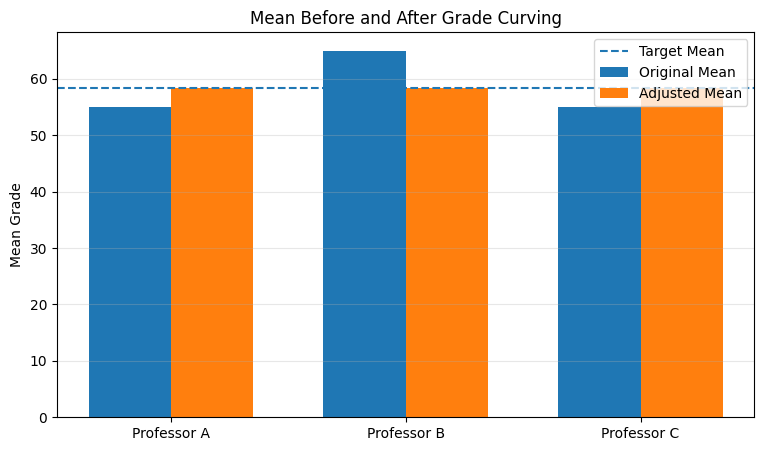

In [22]:
# ============================================================
# CHART 1 — MEAN COMPARISON
# ============================================================

names = [p["name"] for p in professors]

original_means = [
    p["mean"] for p in professors
]

adjusted_means = [
    p["adjusted_mean"] for p in professors
]

x = np.arange(len(names))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width/2,
    original_means,
    width,
    label="Original Mean"
)

plt.bar(
    x + width/2,
    adjusted_means,
    width,
    label="Adjusted Mean"
)

plt.axhline(
    target_mean,
    linestyle="--",
    label="Target Mean"
)

plt.xticks(x, names)
plt.ylabel("Mean Grade")
plt.title("Mean Before and After Grade Curving")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

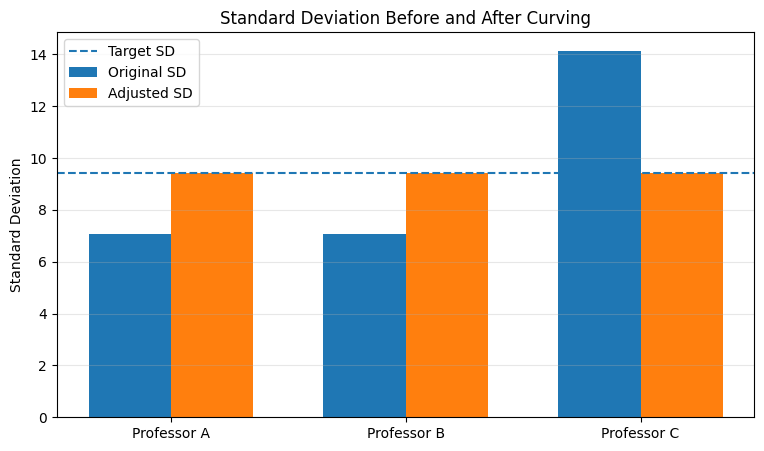

In [23]:
# ============================================================
# CHART 2 — STANDARD DEVIATION
# ============================================================

original_std = [
    p["std"] for p in professors
]

adjusted_std = [
    p["adjusted_std"] for p in professors
]

plt.figure(figsize=(9, 5))

plt.bar(
    x - width/2,
    original_std,
    width,
    label="Original SD"
)

plt.bar(
    x + width/2,
    adjusted_std,
    width,
    label="Adjusted SD"
)

plt.axhline(
    target_std,
    linestyle="--",
    label="Target SD"
)

plt.xticks(x, names)
plt.ylabel("Standard Deviation")
plt.title("Standard Deviation Before and After Curving")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

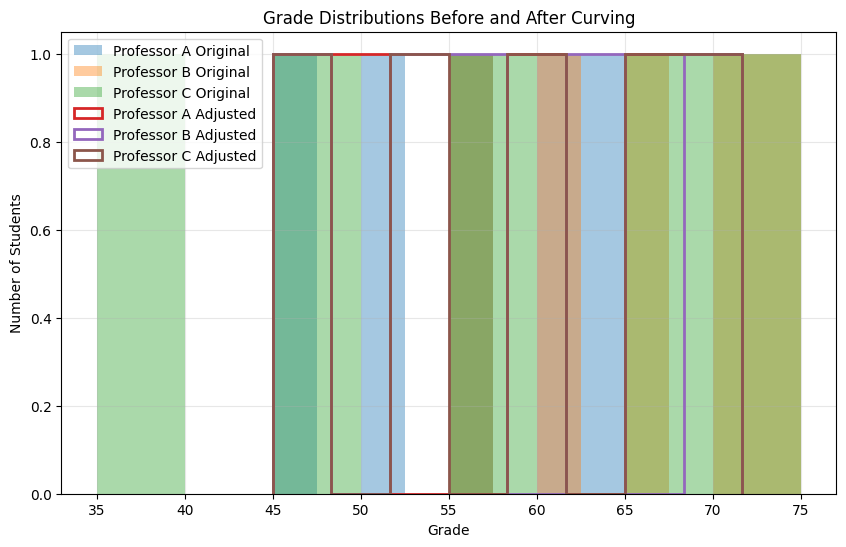

In [24]:

# ============================================================
# CHART 3 — GRADE DISTRIBUTIONS
# ============================================================

plt.figure(figsize=(10, 6))

for p in professors:

    plt.hist(
        p["grades"],
        bins=8,
        alpha=0.4,
        label=f"{p['name']} Original"
    )

for p in professors:

    plt.hist(
        p["adjusted_grades"],
        bins=8,
        histtype="step",
        linewidth=2,
        label=f"{p['name']} Adjusted"
    )

plt.xlabel("Grade")
plt.ylabel("Number of Students")
plt.title("Grade Distributions Before and After Curving")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [25]:
# ============================================================
# FINAL PROJECT SUMMARY
# ============================================================

print("""
==============================================================
                 PROJECT SUMMARY
==============================================================

Project:
Student Grade Curving System

Mathematical concept:
Affine transformation + matrices + Gaussian elimination

Original problem:
Different professors may produce different grade
distributions because their examinations have different
difficulty levels.

Normalization model:

        y = a*x + b

where:

        a = Target SD / Original SD

        b = Target Mean - a × Original Mean

After transformation:

        Mean(y) = Target Mean

        SD(y) = Target SD

Therefore all three professor groups are placed on the
same statistical scale.

Gauss elimination:
A separate 3×3 linear-system engine is included to demonstrate
the required matrix/Gaussian-elimination technique.

Environment:
Python + NumPy + SymPy + Matplotlib
==============================================================
""")


                 PROJECT SUMMARY

Project:
Student Grade Curving System

Mathematical concept:
Affine transformation + matrices + Gaussian elimination

Original problem:
Different professors may produce different grade
distributions because their examinations have different
difficulty levels.

Normalization model:

        y = a*x + b

where:

        a = Target SD / Original SD

        b = Target Mean - a × Original Mean

After transformation:

        Mean(y) = Target Mean

        SD(y) = Target SD

Therefore all three professor groups are placed on the
same statistical scale.

Gauss elimination:
A separate 3×3 linear-system engine is included to demonstrate
the required matrix/Gaussian-elimination technique.

Environment:
Python + NumPy + SymPy + Matplotlib

